In [ ]:
# Cell 1: Imports
import rasterio # reads and write raster data
from rasterio.plot import show # for plotting raster data
import rioxarray as rxr # allows to work with multi-dimentional geospatial data as labelled arrays
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path # for working with file paths

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Cell 2: Load the files
project_root = Path(r"D:\DrishtiSAR")
raw_dir = project_root / "data" / "raw" / "Uttarakhand_Joshimath"

s2_path = raw_dir / "sentinel2_Uttarakhand_Joshimath.tif"
s1_path = raw_dir / "sentinel1_Uttarakhand_Joshimath.tif"

# open both TIF files as xarray DataArrays with rioxarray, which will handle geospatial metadata and masking of no-data values
# masking means that any pixel with a no-data value will be treated as missing data (NaN) in the resulting DataArray, which is important for accurate analysis and visualization
# masked = True ensures that the no-data values are properly handled and do not interfere with calculations or visualizations later on
s2 = rxr.open_rasterio(s2_path, masked=True) 
s1 = rxr.open_rasterio(s1_path, masked=True)

print("Sentinel-2 shape:", s2.shape)   # (bands, height, width)
print("Sentinel-1 shape:", s1.shape)
print("S2 CRS:", s2.rio.crs)
print("S1 CRS:", s1.rio.crs)
#CRS is Coordinate Reference System, which defines how the spatial data is projected on the Earth's surface. It is important to check that both datasets have the same CRS to ensure they are properly aligned for analysis and visualization.

Sentinel-2 shape: (10, 2810, 2918)
Sentinel-1 shape: (2, 2810, 2918)
S2 CRS: EPSG:32644
S1 CRS: EPSG:32644


- Two common CRS are ESPG : 4326 and ESPG : 32644 
<br><b>In simple words :-</b>
- EPSG:4326 — "I drew the whole Earth flat" (lat/lon)
- EPSG:32644 (yours) — "I zoomed into India's zone and drew it flatter" (better for India)

the same 2810 x 2918 for both, which means the height and width match, not the full 3D shape. So Cell 2 was suggesting “same spatial grid size,” not “same shape including bands.”

In [11]:
# Cell 3: Align Sentinel-1 to Sentinel-2 grid
#rio is the geospatial helper attached to a rioxarray object.
print("✅ Checking alignment...")

same_crs = s1.rio.crs == s2.rio.crs
same_res = np.allclose(s1.rio.resolution(), s2.rio.resolution())
same_bounds = np.allclose(s1.rio.bounds(), s2.rio.bounds())

print(f"CRS match: {same_crs} ({s2.rio.crs})")
print(f"Resolution match: {same_res}")
print(f"Bounds match: {same_bounds}")
print(f"Spatial shape match: {s1.shape[1:] == s2.shape[1:]}")
print(f"Band count differs as expected: S2={s2.shape[0]}, S1={s1.shape[0]}")

if not (same_crs and same_res and same_bounds and s1.shape[1:] == s2.shape[1:]):
    print("Reprojecting Sentinel-1 to match Sentinel-2 exactly...")
    s1 = s1.rio.reproject_match(s2)

print("\n✅ Final alignment check:")
print(f"S2 shape: {s2.shape}")
print(f"S1 shape: {s1.shape}")
print(f"S2 CRS: {s2.rio.crs}")
print(f"S1 CRS: {s1.rio.crs}")
print(f"S2 bounds: {s2.rio.bounds()}")
print(f"S1 bounds: {s1.rio.bounds()}")
print("\n✅ Data ready for fusion!")

✅ Checking alignment...
CRS match: True (EPSG:32644)
Resolution match: True
Bounds match: True
Spatial shape match: True
Band count differs as expected: S2=10, S1=2

✅ Final alignment check:
S2 shape: (10, 2810, 2918)
S1 shape: (2, 2810, 2918)
S2 CRS: EPSG:32644
S1 CRS: EPSG:32644
S2 bounds: (341410.0, 3358340.0, 370590.0, 3386440.0)
S1 bounds: (341408.28519021143, 3358335.2536770036, 370588.28519021143, 3386435.2536770036)

✅ Data ready for fusion!


A simple ablation study for now on 256X256 pixel patch due to system constraints
<br> 
- Later will move to a 512X512 pixel for final results and add more AOIs (Assam , Bihar , kerala, etc..)
- s2_patches = create_patches(s2_np, patch_size=512, overlap=64) #Just by changing this

In [12]:
# Cell 4: Create small patches (256x256) with 32 pixel overlap for training
def create_patches(image, patch_size=256, overlap=0):
    """Cut large image into small patches"""
    patches = []
    h, w = image.shape[1], image.shape[2]
    
    for i in range(0, h - patch_size + 1, patch_size - overlap):# 0, 224, 448, 672, ...
        for j in range(0, w - patch_size + 1, patch_size - overlap):
            patch = image[:, i:i+patch_size, j:j+patch_size]
            patches.append(patch)
    return np.array(patches)

# Convert to numpy
s2_np = s2.values.astype(np.float32)
s1_np = s1.values.astype(np.float32)

s2_patches = create_patches(s2_np, patch_size=256, overlap=32)
s1_patches = create_patches(s1_np, patch_size=256, overlap=32)

print(f"Created {len(s2_patches)} patches of size 256x256")
print(f"Created {len(s1_patches)} patches of size 256x256")

Created 144 patches of size 256x256
Created 144 patches of size 256x256


In [ ]:
# Cell 5 : Save the patches

from pathlib import Path
import numpy as np

project_root = Path(r"D:\DrishtiSAR")
patch_dir = project_root / "data" / "patches" / "Uttarakhand_Joshimath"

# Save the patches
np.save(patch_dir / "s2_patches.npy", s2_patches)
np.save(patch_dir / "s1_patches.npy", s1_patches)

print("Patches saved successfully!")
print(f"Total patches saved: {s2_patches.shape[0]}")
print(f"Location: {patch_dir}")
print(f"s2 file: {patch_dir / 's2_patches.npy'}")
print(f"s1 file: {patch_dir / 's1_patches.npy'}")

Patches saved successfully!
Total patches saved: 144
Location: c:\Users\LENOVO\Desktop\DrishtiSAR\data\patches\Uttarakhand_Joshimath
s2 file: c:\Users\LENOVO\Desktop\DrishtiSAR\data\patches\Uttarakhand_Joshimath\s2_patches.npy
s1 file: c:\Users\LENOVO\Desktop\DrishtiSAR\data\patches\Uttarakhand_Joshimath\s1_patches.npy


I created patches(.npy) and .tiff files for august and september months for the s1 and s2 patches but the results very poor for the s2(The results were completely masked) , so better results I changed the time to 5 months (Nov 2025- Mar 2026) for better processing for diffusion models.

aug-sept visualization is below :
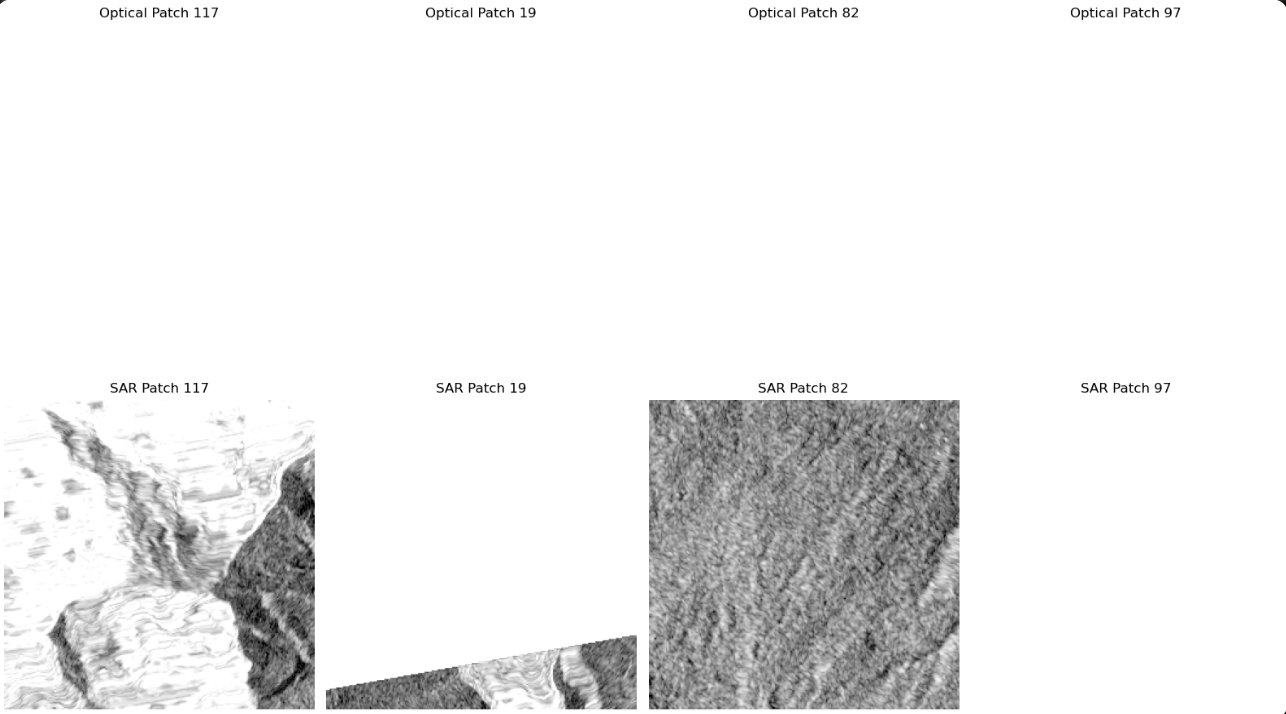

Loaded 144 patches


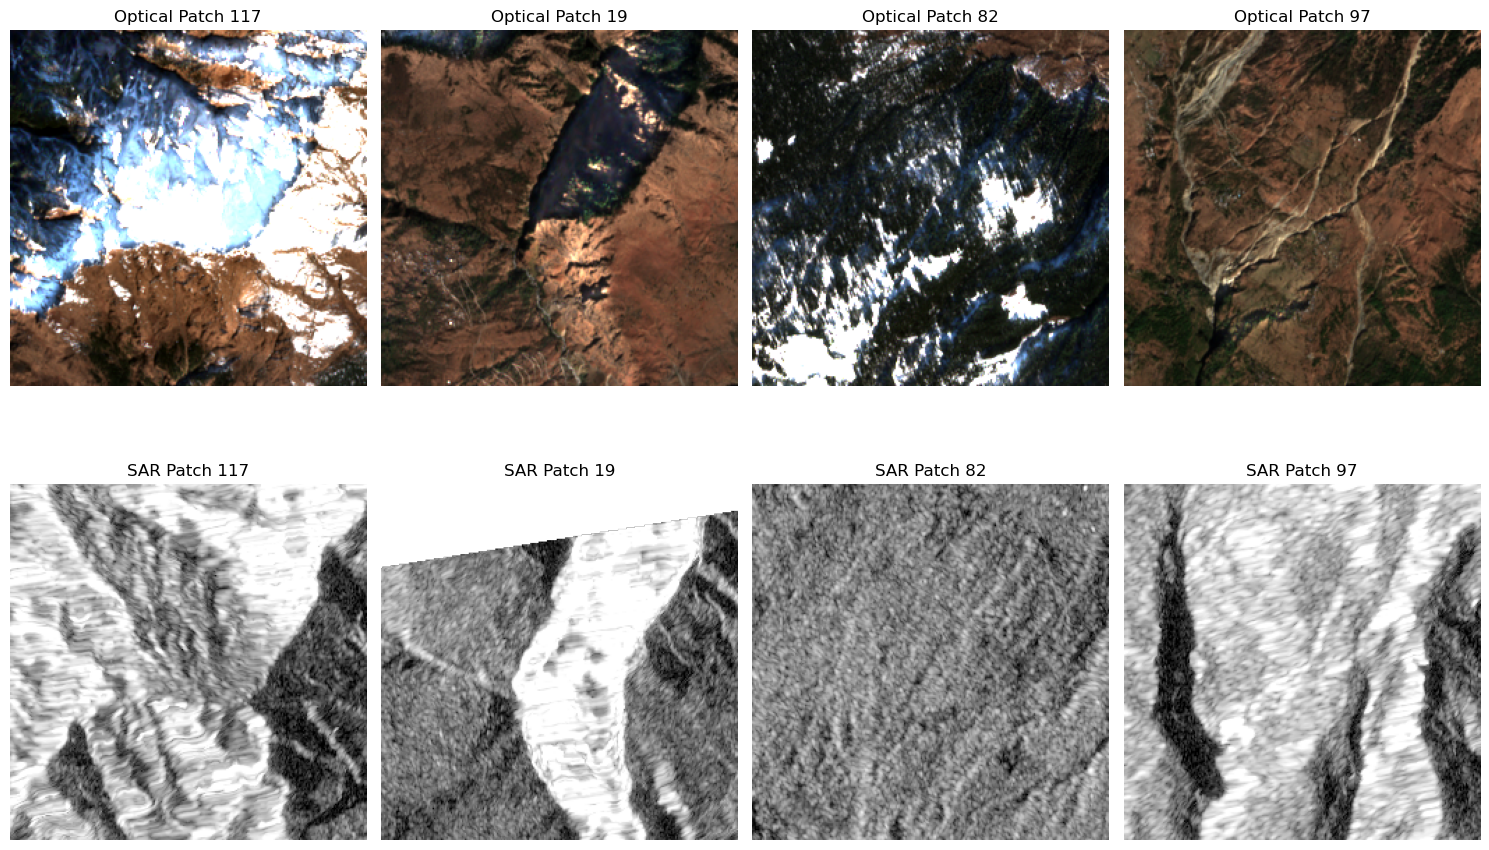

In [ ]:
# === VISUALIZATION CELL (NOV 2025 -MAR 2026)===

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load patches
project_root = Path(r"D:\DrishtiSAR")
patch_dir = project_root / "data" / "patches" / "Uttarakhand_Joshimath"

s2_patches = np.load(patch_dir / "s2_patches.npy")
s1_patches = np.load(patch_dir / "s1_patches.npy")

print(f"Loaded {s2_patches.shape[0]} patches")

# Show 4 random patch pairs
plt.figure(figsize=(15, 10))
np.random.seed(42)
indices = np.random.choice(len(s2_patches), 4, replace=False) # randomly select 4 patch indices without replacement

for i, idx in enumerate(indices):
    # Sentinel-2 (Optical)
    plt.subplot(2, 4, i+1)
    rgb = s2_patches[idx][[2,1,0]]          # B4, B3, B2 → RGB
    rgb = np.clip(rgb / 3000, 0, 1)         # Simple stretch
    plt.imshow(rgb.transpose(1, 2, 0)) #imshow expects (H, W, C) so transpose from (bands, H, W) to (H, W, bands) and show the RGB image.
    plt.title(f"Optical Patch {idx}")
    plt.axis('off')
    
    # Sentinel-1 (SAR)
    plt.subplot(2, 4, i+5)
    plt.imshow(s1_patches[idx][0], cmap='gray', vmin=-25, vmax=0)  # VV band
    plt.title(f"SAR Patch {idx}")
    plt.axis('off')

plt.tight_layout()
plt.show()

* We need to do normalization because Neural networks works best with [0,1] range 
*Raw Sentinel-2 values: 0–10,000 while Normalized: 0–1
*Neural networks are sensitive to scale. Large values (0–10,000) can cause:

- Exploding gradients (training becomes unstable)
- Slower convergence
- Poor learning<br>
* Normalization makes both on a comparable scale so the model treats them fairly. Also, faster training as smaller weight updates and Better Generalization

- Why S1 Stays at -25 to 0 (Not 0 to 1) : 
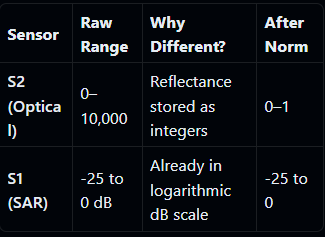
- For Sentinel-1 (SAR):

* Values are already in decibels (dB), which is a logarithmic scale
* -25 dB = very weak signal (water, shadows)
* 0 dB = strong signal (buildings, rough terrain)
* The negative values are meaningful — they tell you signal strength

In [ ]:
# === NORMALIZATION and SAVING ===

import numpy as np
from pathlib import Path

project_root = Path(r"D:\DrishtiSAR")
patch_dir = project_root / "data" / "patches" / "Uttarakhand_Joshimath"

# Load patches
s2_patches = np.load(patch_dir / "s2_patches.npy")
s1_patches = np.load(patch_dir / "s1_patches.npy")

print("Original S2 value range:", s2_patches.min(), "to", s2_patches.max())

# Robust normalization for Sentinel-2 (divide by 10000 is standard for SR data)
s2_norm = s2_patches.astype(np.float32) / 10000.0
s1_norm = s1_patches.astype(np.float32)   # SAR values are already in good range (-25 to 0)

# Clip to reasonable range
s2_norm = np.clip(s2_norm, 0, 1)

print("After normalization - S2 range:", s2_norm.min(), "to", s2_norm.max())

# Save normalized versions
np.save(patch_dir / "s2_patches_norm.npy", s2_norm)
np.save(patch_dir / "s1_patches_norm.npy", s1_norm)

print(f"✅ Normalized patches saved successfully in {patch_dir}")

Original S2 value range: nan to nan
After normalization - S2 range: nan to nan
✅ Normalized patches saved successfully in c:\Users\LENOVO\Desktop\DrishtiSAR\data\patches\Uttarakhand_Joshimath


In [16]:
# === CREATE PAIRED DATASET ===

paired_data = {
    "s2": s2_norm,      # Clean optical (target)
    "s1": s1_norm       # SAR (condition/input)
}

np.save(patch_dir / "paired_patches.npy", paired_data) # Save the paired dataset as a single .npy file containing a dictionary with both S2 and S1 data

print(f"✅ Paired dataset created with {s2_norm.shape[0]} samples!")
print("Shape of each pair:", s2_norm.shape[1:])  # (bands, 256, 256)

✅ Paired dataset created with 144 samples!
Shape of each pair: (10, 256, 256)


In [17]:
# === FINAL VERIFICATION ===
print("FINAL CHECK")
print(f"Total good patches     : {s2_norm.shape[0]}") # Total number of patches available for training after filtering out any bad patches (if any)
print(f"S2 normalized shape    : {s2_norm.shape}") # Shape of the normalized S2 patches (num_patches, bands, height, width)
print(f"S1 normalized shape    : {s1_norm.shape}") # Shape of the normalized S1 patches (num_patches, bands, height, width)
print(f"Paired file exists     : {(patch_dir / 'paired_patches.npy').exists()}") # Check if the paired dataset file exists

FINAL CHECK
Total good patches     : 144
S2 normalized shape    : (144, 10, 256, 256)
S1 normalized shape    : (144, 2, 256, 256)
Paired file exists     : True
